# Projekat: Analiza Sentimenta Steam Recenzija
## Tema: Primena Vestackih Neuronskih Mreza

**Dataset:** [Steam Reviews](https://www.kaggle.com/datasets/luthfim/steam-reviews-dataset)

**Cilj:** Predvidjanje sentimenta recenzije (pozitivno/negativno) na osnovu teksta.

**Biblioteke**: TensorFlow/Keras, scikit-learn, pandas, numpy

## Ucitavanje biblioteka i podataka

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, GlobalAveragePooling1D, GRU, Bidirectional, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('data/steam_reviews.csv')

df.head()

,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
0,2019-02-10,2,4,578,False,Recommended,&gt Played as German Reich&gt Declare war on B...,Expansion - Hearts of Iron IV: Man the Guns
1,2019-02-10,0,0,184,False,Recommended,yes.,Expansion - Hearts of Iron IV: Man the Guns
2,2019-02-07,0,0,892,False,Recommended,Very good game although a bit overpriced in my...,Expansion - Hearts of Iron IV: Man the Guns
3,2018-06-14,126,1086,676,False,Recommended,Out of all the reviews I wrote This one is pro...,Dead by Daylight
4,2017-06-20,85,2139,612,False,Recommended,Disclaimer I survivor main. I play games for f...,Dead by Daylight


## Deskriptivna analiza

### Istrazivanje dataseta

In [3]:
print(f"Shape: {df.shape}")
print("\nNaziv kolona:")
print(df.columns.tolist())

print('\nInformacije o datasetu:')
print(df.info())
print('\nDistribucija sentimenta')
print(df['recommendation'].value_counts())
print('Statistike')
print(df.describe())

Shape: (434891, 8)

Naziv kolona:
['date_posted', 'funny', 'helpful', 'hour_played', 'is_early_access_review', 'recommendation', 'review', 'title']

Informacije o datasetu:
<class 'pandas.DataFrame'>
RangeIndex: 434891 entries, 0 to 434890
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   date_posted             434891 non-null  str  
 1   funny                   434891 non-null  int64
 2   helpful                 434891 non-null  int64
 3   hour_played             434891 non-null  int64
 4   is_early_access_review  434891 non-null  bool 
 5   recommendation          434891 non-null  str  
 6   review                  433375 non-null  str  
 7   title                   434891 non-null  str  
dtypes: bool(1), int64(3), str(4)
memory usage: 23.6 MB
None

Distribucija sentimenta
recommendation
Recommended        303593
Not Recommended    131298
Name: count, dtype: int64
Statistike
              funn

In [4]:
print('\nBroj nedostajucih vrednosti:\n')
print(df.isnull().sum())


Broj nedostajucih vrednosti:

date_posted                  0
funny                        0
helpful                      0
hour_played                  0
is_early_access_review       0
recommendation               0
review                    1516
title                        0
dtype: int64


### Data cleanup

In [5]:
df = df.copy()

In [6]:
missing_values = df['review'].isnull().sum()
print(f'Broj redova pre ciscenja: {len(df)}')
print(f"Nedostajuce vrednosti u 'review': {missing_values}")

df = df.dropna(subset=['review'])

df = df.reset_index(drop=True)

null_count = df['review'].isnull().sum()
print(f'\nBroj redova posle ciscenja: {len(df)}')
print(f'Nedostajuce vrednosti nakon ciscenja: {null_count}')
print(f'Uklonjeno redova: {missing_values}')

Broj redova pre ciscenja: 434891
Nedostajuce vrednosti u 'review': 1516

Broj redova posle ciscenja: 433375
Nedostajuce vrednosti nakon ciscenja: 0
Uklonjeno redova: 1516


### Distribucija Sentimenta

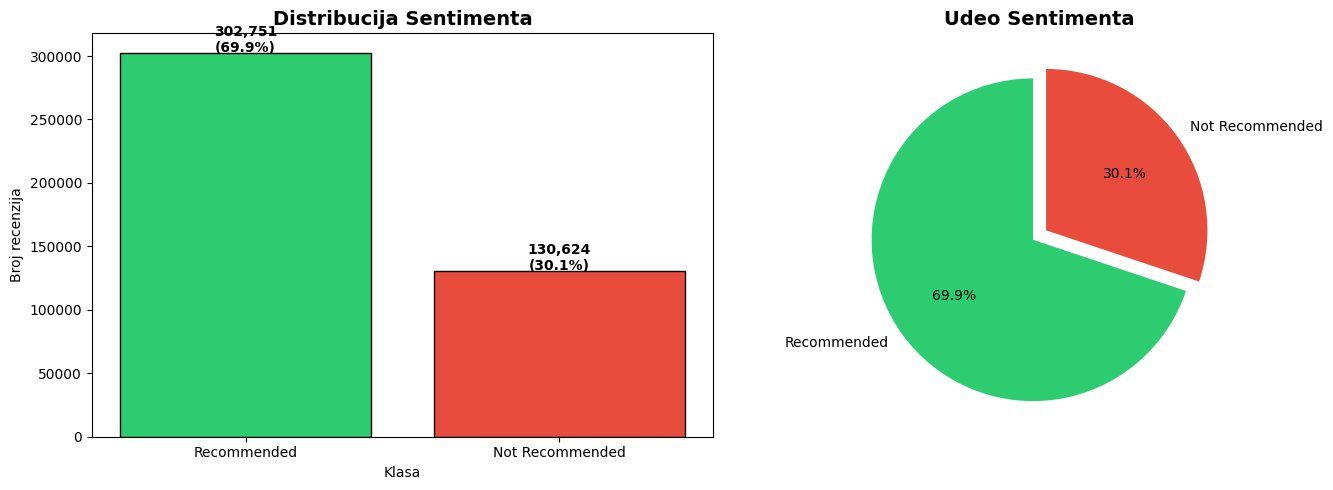

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sentiment_counts = df['recommendation'].value_counts()

axes[0].bar(sentiment_counts.index, sentiment_counts.values, 
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribucija Sentimenta', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Broj recenzija')

for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', fontweight='bold')

axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Udeo Sentimenta', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Statistike duzine recenzija
                    count   mean     std  min  25%   50%   75%     max
recommendation                                                        
Not Recommended  130624.0  54.63  101.96  1.0  7.0  22.0  59.0  2895.0
Recommended      302751.0  34.46   78.94  1.0  4.0  11.0  32.0  7984.0


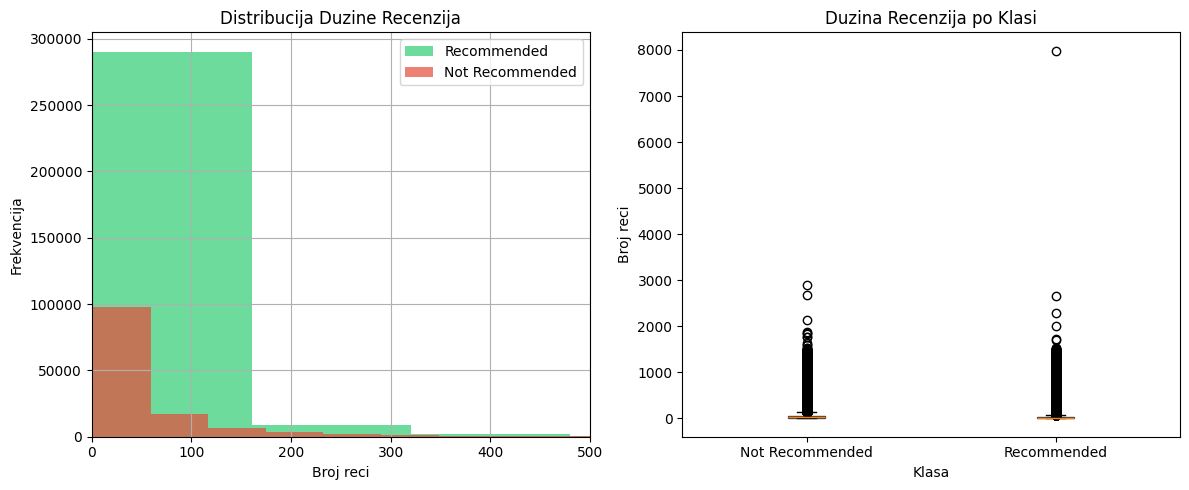

In [8]:
df['review_len'] = df['review'].astype(str).apply(lambda x: len(x.split()))

print("Statistike duzine recenzija")
print(df.groupby('recommendation')['review_len'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df[df['recommendation'] == 'Recommended']['review_len'].hist(
    bins=50, color='#2ecc71', alpha=0.7, label='Recommended', ax=axes[0])
df[df['recommendation'] == 'Not Recommended']['review_len'].hist(
    bins=50, color='#e74c3c', alpha=0.7, label='Not Recommended', ax=axes[0])
axes[0].set_xlim(0, 500)
axes[0].set_title('Distribucija Duzine Recenzija')
axes[0].set_xlabel('Broj reci')
axes[0].set_ylabel('Frekvencija')
axes[0].legend()

recommended = df[df['recommendation'] == 'Recommended']['review_len']
not_recommended = df[df['recommendation'] == 'Not Recommended']['review_len']

axes[1].boxplot([not_recommended, recommended],
                labels=['Not Recommended', 'Recommended'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Duzina Recenzija po Klasi')
axes[1].set_xlabel('Klasa')
axes[1].set_ylabel('Broj reci')

plt.tight_layout()
plt.show()

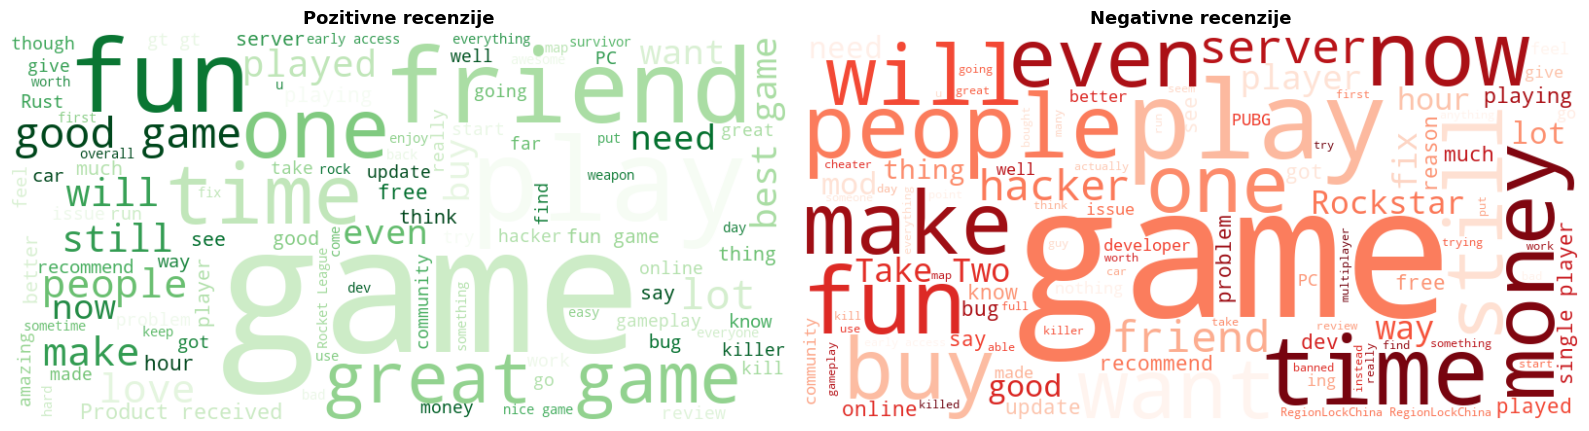

In [9]:
positive_text = ' '.join(
    df[df['recommendation'] == 'Recommended']['review'].astype(str).tolist()
)

negative_text = ' '.join(
    df[df['recommendation'] == 'Not Recommended']['review'].astype(str).tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Pozitivne recenzije', fontsize=13, fontweight='bold')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negativne recenzije', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## Priprema teksta

### Ciscenje podataka

In [10]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['review_clean'] = df['review'].apply(clean_text)

for i in range(3):
    print(f"[{i+1}] Original:\n{df['review'].iloc[i]}")
    print(f"    Ociscen:\n{df['review_clean'].iloc[i]}")
    print()

[1] Original:
&gt Played as German Reich&gt Declare war on Belgium&gt Can't break Belgium so go through France&gt Capitulate France in order to get to Belgium&gt Get True Blitzkrieg achievementThis game is dad
    Ociscen:
gt played as german reichgt declare war on belgiumgt cant break belgium so go through francegt capitulate france in order to get to belgiumgt get true blitzkrieg achievementthis game is dad

[2] Original:
yes.
    Ociscen:
yes

[3] Original:
Very good game although a bit overpriced in my opinion. I'd prefer playing the game with mods (historical accuracy so on) although the vanilla version is good aswell. 7/10
    Ociscen:
very good game although a bit overpriced in my opinion id prefer playing the game with mods historical accuracy so on although the vanilla version is good aswell



### Enkodiranje klasa

In [11]:
df['label'] = (df['recommendation'] == 'Recommended').astype(int)

print("'Recommended': 1")
print("'Not Recommended': 0")
print()
print(df['label'].value_counts())

'Recommended': 1
'Not Recommended': 0

label
1    302751
0    130624
Name: count, dtype: int64


### Train/Test split

In [12]:
X = df['review_clean'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

print(f'Ukupno recenzija: {len(df):,}')
print(f'Train: {len(X_train):,} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test: {len(X_test):,} ({len(X_test)/len(df)*100:.0f}%)')

Ukupno recenzija: 433,375
Train: 346,700 (80%)
Test: 86,675 (20%)


### Balansiranje klasa (Class Weights)

In [13]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print(f"0 - Not Recommended: {class_weight_dict[0]:.4f}")
print(f"1 - Recommended:    {class_weight_dict[1]:.4f}")
print()
print(f"Greska na negativnoj recenziji kosta {class_weight_dict[0]:.2f}x vise")
print(f"Greska na pozitivnoj recenziji kosta {class_weight_dict[1]:.2f}x vise")

0 - Not Recommended: 1.6589
1 - Recommended:    0.7157

Greska na negativnoj recenziji kosta 1.66x vise
Greska na pozitivnoj recenziji kosta 0.72x vise


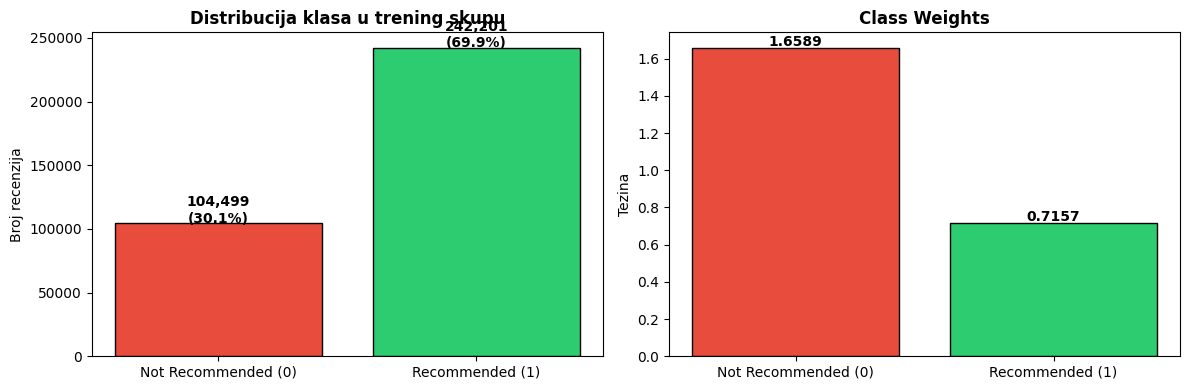

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

klase = ['Not Recommended (0)', 'Recommended (1)']
counts = [sum(y_train == 0), sum(y_train == 1)]
axes[0].bar(klase, counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribucija klasa u trening skupu', fontweight='bold')
axes[0].set_ylabel('Broj recenzija')
for i, v in enumerate(counts):
    axes[0].text(i, v + 500, f'{v:,}\n({v/sum(counts)*100:.1f}%)',
                ha='center', fontweight='bold')

weights = [class_weight_dict[0], class_weight_dict[1]]
axes[1].bar(klase, weights, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Class Weights', fontweight='bold')
axes[1].set_ylabel('Tezina')
for i, v in enumerate(weights):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Tokenizacija

In [15]:
MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Velicina recnika:    {len(tokenizer.word_index):,} jedinstvenih reci")
print(f"Koristimo top:       {MAX_WORDS:,} reci")
print(f"Max duzina:          {MAX_LEN} reci po recenziji")
print(f"Shape X_train_pad:   {X_train_pad.shape}")
print(f"Shape X_test_pad:    {X_test_pad.shape}")

Velicina recnika:    236,959 jedinstvenih reci
Koristimo top:       20,000 reci
Max duzina:          200 reci po recenziji
Shape X_train_pad:   (346700, 200)
Shape X_test_pad:    (86675, 200)


## Kreiranje i treniranje neuronske mreze

Za sve modele koristimo **binary crossentropy** loss funkciju. Meri koliko je model siguran u
pogresnom smeru (sto je model sigurniji u pogresnoj predikciji, to je kazna veca).
Kao optimizer koriscen je **Adam** koji automatski prilagodjavala brzinu ucenja
tokom treniranja.

In [37]:
EMBEDDING_DIM = 64

models = {
    'LSTM': Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        LSTM(64, return_sequences=False),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ]),
    'GRU': Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        GRU(64, return_sequences=False),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ]),
    'BiLSTM': Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ]),
    'CNN': Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
}

for name, m in models.items():
    m.build(input_shape=(None, MAX_LEN))
    m.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    print(f"{name} Summary:")
    m.summary()
    print()

LSTM Summary:


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,089 (5.01 MB)

 Trainable params: 1,313,089 (5.01 MB)

...

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_25 (Embedding)        │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 196, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,409 (5.07 MB)

 Trainable params: 1,329,409 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

### Treniranje modela

In [39]:
histories = {}

for name, m in models.items():
    print(f"\nTreniranje: {name}\n")
    es = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    h = m.fit(
        X_train_pad, y_train,
        epochs=10,
        batch_size=512,
        validation_split=0.1,
        callbacks=[es],
        class_weight=class_weight_dict
    )
    histories[name] = h
    print(f"{name} zavrseno!\n")


Treniranje: LSTM

Epoch 1/10
610/610 ━━━━━━━━━━━━━━━━━━━━ 186s 305ms/step - accuracy: 0.5705 - loss: 0.6915 - val_accuracy: 0.6970 - val_loss: 0.6921
Epoch 2/10
610/610 ━━━━━━━━━━━━━━━━━━━━ 187s 306ms/step - accuracy: 0.7022 - loss: 0.6455 - val_accuracy: 0.7749 - val_loss: 0.5906
Epoch 3/10
610/610 ━━━━━━━━━━━━━━━━━━━━ 171s 280ms/step - accuracy: 0.6961 - loss: 0.6322 - val_accuracy: 0.7359 - val_loss: 0.5879
Epoch 4/10
610/610 ━━━━━━━━━━━━━━━━━━━━ 174s 285ms/step - accuracy: 0.6225 - loss: 0.6526 - val_accuracy: 0.7003 - val_loss: 0.6816
Epoch 5/10
610/610 ━━━━━━━━━━━━━━━━━━━━ 176s 288ms/step - accuracy: 0.6839 - loss: 0.5986 - val_accuracy: 0.8444 - val_loss: 0.3968
Epoch 6/10
610/610 ━━━━━━━━━━━━━━━━━━━━ 185s 304ms/step - accuracy: 0.8473 - loss: 0.3726 - val_accuracy: 0.8230 - val_loss: 0.4020
Epoch 7/10
610/610 ━━━━━━━━━━━━━━━━━━━━ 178s 291ms/step - accuracy: 0.8663 - loss: 0.3183 - val_accuracy: 0.8589 - val_loss: 0.3334
Epoch 8/10
610/610 ━━━━━━━━━━━━━━━━━━━━ 176s 288ms/step -

## Vizualizacija rezultata

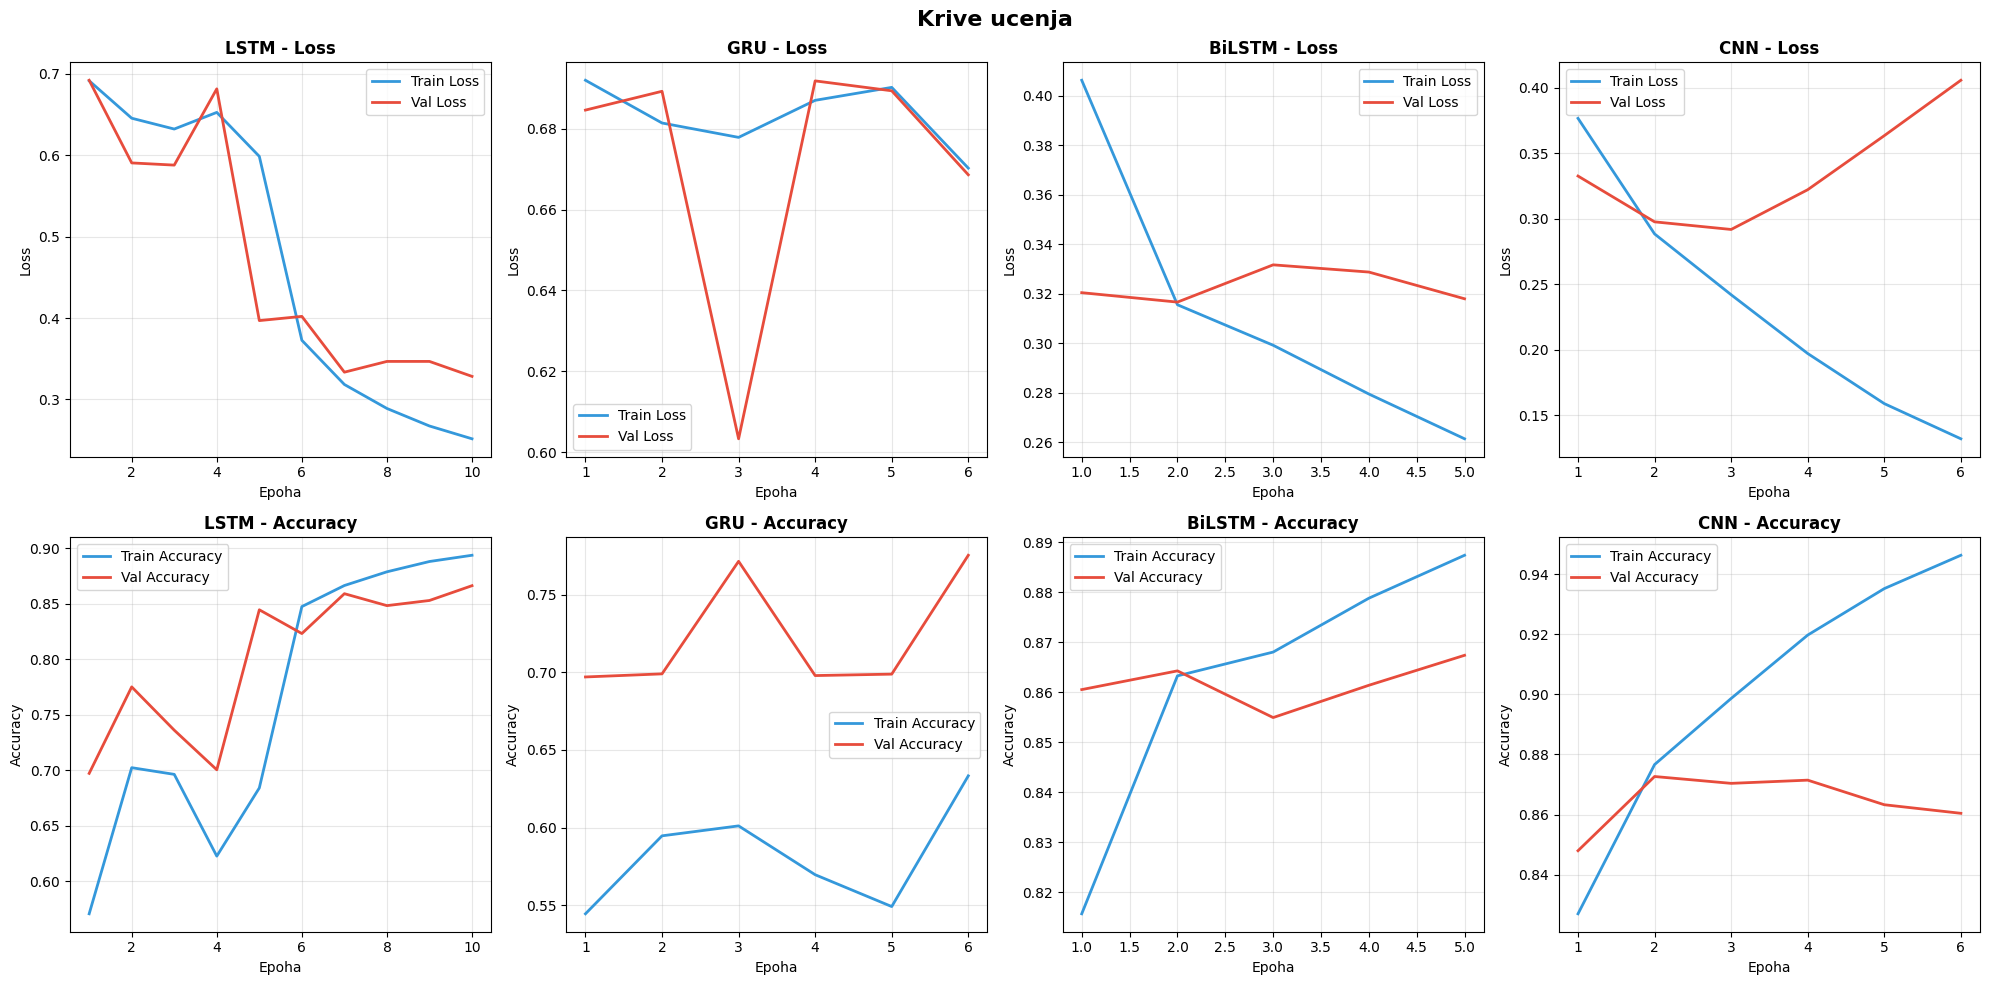

In [43]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, (name, h) in enumerate(histories.items()):
    epochs_range = range(1, len(h.history['loss']) + 1)

    axes[0][idx].plot(epochs_range, h.history['loss'], label='Train Loss', color='#3498db', linewidth=2)
    axes[0][idx].plot(epochs_range, h.history['val_loss'], label='Val Loss', color='#e74c3c', linewidth=2)
    axes[0][idx].set_title(f'{name} - Loss', fontweight='bold')
    axes[0][idx].set_xlabel('Epoha')
    axes[0][idx].set_ylabel('Loss')
    axes[0][idx].legend()
    axes[0][idx].grid(True, alpha=0.3)

    axes[1][idx].plot(epochs_range, h.history['accuracy'], label='Train Accuracy', color='#3498db', linewidth=2)
    axes[1][idx].plot(epochs_range, h.history['val_accuracy'], label='Val Accuracy', color='#e74c3c', linewidth=2)
    axes[1][idx].set_title(f'{name} - Accuracy', fontweight='bold')
    axes[1][idx].set_xlabel('Epoha')
    axes[1][idx].set_ylabel('Accuracy')
    axes[1][idx].legend()
    axes[1][idx].grid(True, alpha=0.3)

plt.suptitle('Krive ucenja', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Evaluacija

In [42]:
results = {}

for name, m in models.items():
    loss, accuracy = m.evaluate(X_test_pad, y_test, verbose=0)
    results[name] = {'loss': loss, 'accuracy': accuracy}
    print(f"{name:10} | Loss: {loss:.4f} | Accuracy: {accuracy*100:.2f}%")

LSTM       | Loss: 0.3241 | Accuracy: 86.69%
GRU        | Loss: 0.6023 | Accuracy: 77.11%
BiLSTM     | Loss: 0.3162 | Accuracy: 86.47%
CNN        | Loss: 0.2932 | Accuracy: 87.10%


### Confusion Matrix i Classification Report

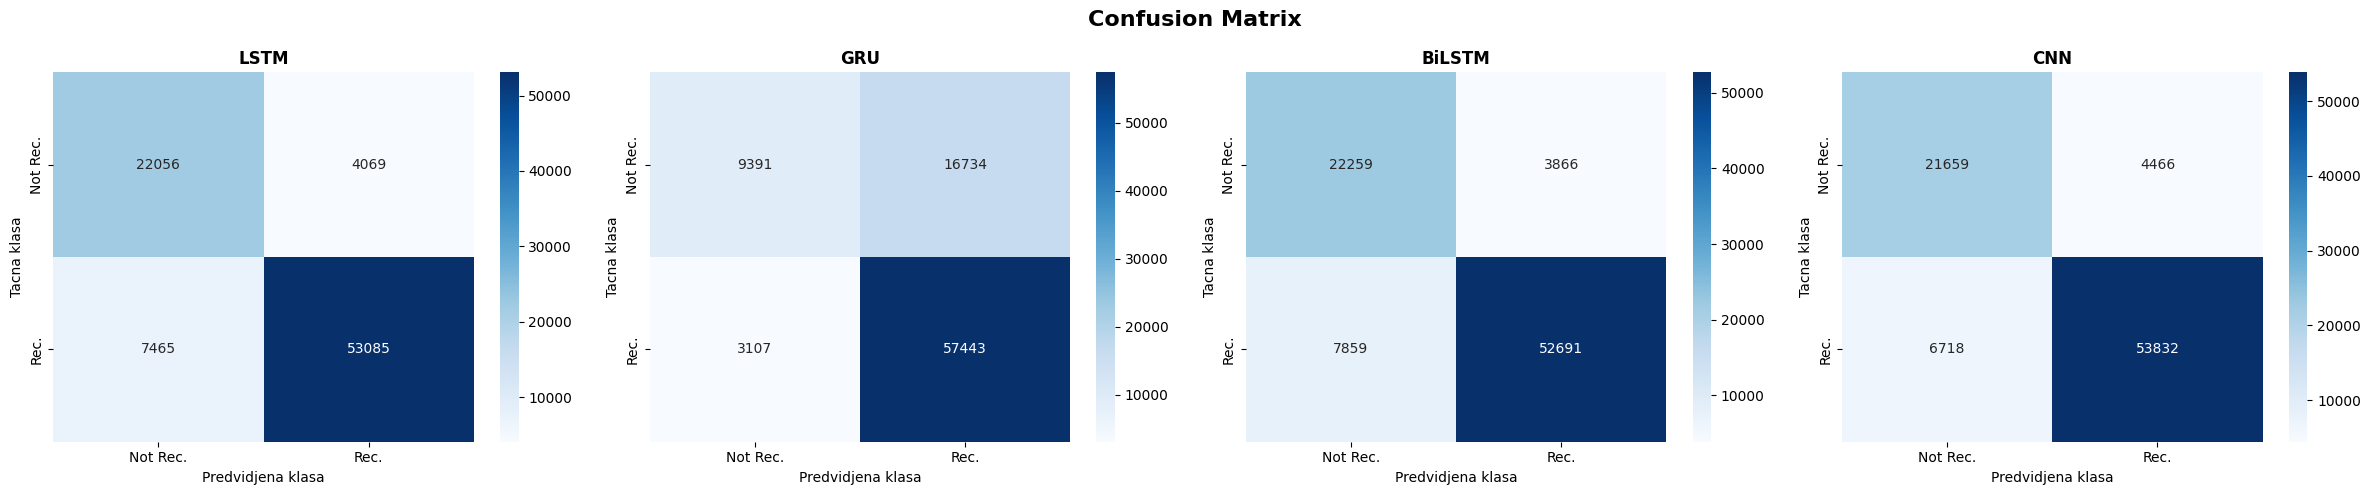


LSTM
                 precision    recall  f1-score   support

Not Recommended       0.75      0.84      0.79     26125
    Recommended       0.93      0.88      0.90     60550

       accuracy                           0.87     86675
      macro avg       0.84      0.86      0.85     86675
   weighted avg       0.87      0.87      0.87     86675


GRU
                 precision    recall  f1-score   support

Not Recommended       0.75      0.36      0.49     26125
    Recommended       0.77      0.95      0.85     60550

       accuracy                           0.77     86675
      macro avg       0.76      0.65      0.67     86675
   weighted avg       0.77      0.77      0.74     86675


BiLSTM
                 precision    recall  f1-score   support

Not Recommended       0.74      0.85      0.79     26125
    Recommended       0.93      0.87      0.90     60550

       accuracy                           0.86     86675
      macro avg       0.84      0.86      0.85     86675
   w

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for idx, (name, m) in enumerate(models.items()):
    y_pred_prob = m.predict(X_test_pad, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Rec.', 'Rec.'],
                yticklabels=['Not Rec.', 'Rec.'])
    axes[idx].set_title(f'{name}', fontweight='bold')
    axes[idx].set_ylabel('Tacna klasa')
    axes[idx].set_xlabel('Predvidjena klasa')

plt.suptitle('Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

for name, m in models.items():
    y_pred_prob = m.predict(X_test_pad, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred,
          target_names=['Not Recommended', 'Recommended']))

### Poredjenje modela

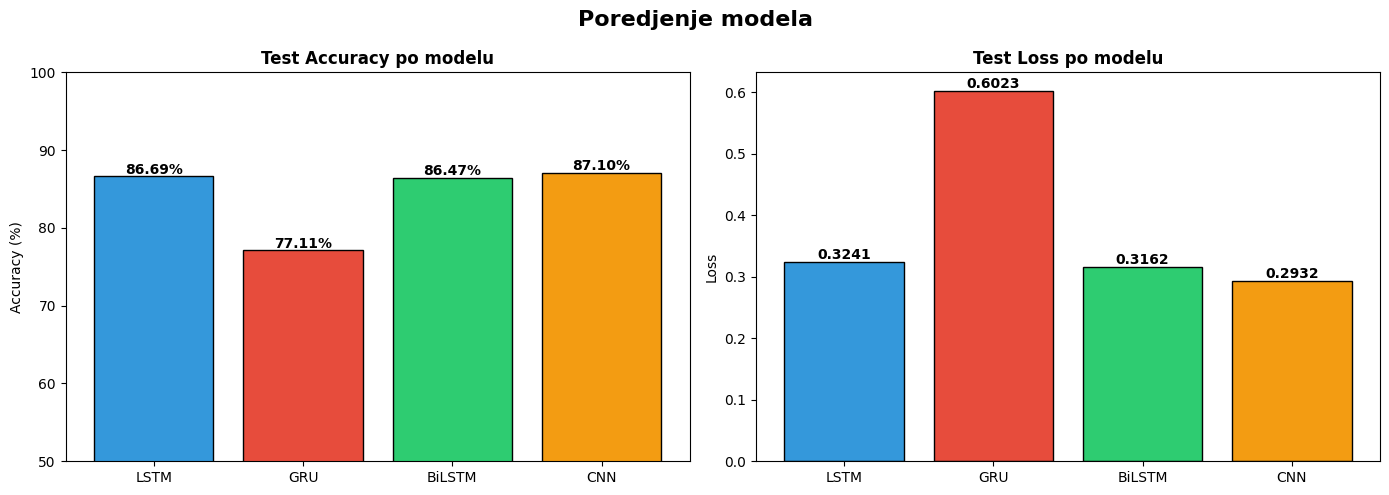

In [46]:
names = list(results.keys())
accuracies = [results[n]['accuracy'] * 100 for n in names]
losses = [results[n]['loss'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[0].set_title('Test Accuracy po modelu', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(50, 100)
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.2f}%', ha='center', fontweight='bold')

bars2 = axes[1].bar(names, losses, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'], edgecolor='black')
axes[1].set_title('Test Loss po modelu', fontweight='bold')
axes[1].set_ylabel('Loss')
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', fontweight='bold')

plt.suptitle('Poredjenje modela', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Zakljucak

U okviru ovog projekta sprovedena je analiza sentimenta Steam recenzija
koriscenjem cetiri arhitekture dubokih neuronskih mreza: LSTM, GRU, BiLSTM i CNN.
Na osnovu dobijenih rezultata, metrika performansi i vizuelizacije procesa ucenja,
izvedeni su sledeci zakljucci:

---

### Priprema podataka

Inicijalna faza projekta pokazala je da je precizno ciscenje i priprema teksta
kljucno za kvalitet modela. Implementacijom funkcije ciscenja koja uklanja linkove,
specijalne karaktere i interpunkciju, kao i tokenizacijom sa recnikom od 20.000
najcescih reci i maksimalnom duzinom sekvence od 200 tokena, podaci su pripremljeni
za efikasno treniranje. Zbog neravnoteze klasa (69.9% pozitivnih vs 30.1%
negativnih recenzija), primenjena je tehnika class weights koja je modelu nalagala
da greske na manjinskoj klasi teze 1.66x vise.

---

### Poredjenje modela

| Model  | Accuracy | Loss   | F1 macro |
|--------|----------|--------|----------|
| CNN    | 87.10%   | 0.2932 | 0.85     |
| LSTM   | 86.69%   | 0.3241 | 0.85     |
| BiLSTM | 86.47%   | 0.3162 | 0.85     |
| GRU    | 77.11%   | 0.6023 | 0.67     |

---

### Analiza modela

**CNN** se pokazao kao najuspesniji model sa accuracy od 87.10% i najnizim
test loss-om od 0.2932. Kljucni faktor njegovog uspeha je sposobnost Conv1D
sloja da detektuje lokalne obrasce i kljucne fraze u tekstu nezavisno od njihove
pozicije u recenziji. Medjutim, CNN je pokazao najizrazeniji overfitting. Train
accuracy je dostigla 94.64% dok je val accuracy stagnirala na 86-87%.

**LSTM i BiLSTM** su postigli prakticno identicne rezultate (86.69% i 86.47%
accuracy, F1 macro 0.85 za oba), pri cemu je BiLSTM pokazao stabilnije krive
ucenja i brzu konvergenciju vec od prve epohe. Ovo je ocekivano jer BiLSTM cita
tekst u oba smera, sto mu daje bolji uvid u kontekst svake reci.

**GRU** se pokazao kao najslabiji model sa accuracy od 77.11% i loss-om od
0.6023. Analiza krivih ucenja pokazuje nestabilno treniranje sa velikim
oscilacijama val_loss-a, sto ukazuje da model nije konvergirao u ovoj
konfiguraciji.

---

### Analiza gresaka

Detaljnom analizom confusion matrica utvrdjeno je da svi modeli (osim GRU)
postizu slican uzorak gresaka. Teze im je da prepoznaju negativne recenzije
(Not Recommended) nego pozitivne. Ovo je ocekivano s obzirom na to da pozitivne
recenzije imaju jasnije i direktnije formulacije, dok negativne cesto sadrze
sarcazam ili ambivalentan tekst koji je teze klasifikovati.

---

### Moguca poboljsanja

Rezultati sugerisu da bi sledeca poboljsanja mogla povecati performanse modela:

* Primena pre-treniranih embedding vektora kao sto su GloVe ili Word2Vec
* Dodavanje BatchNormalization i SpatialDropout1D slojeva
* Primena naprednijih arhitektura kao sto je BERT koji bi bolje razumeo
  kontekst i sarcazam u tekstu
* Prikupljanje vise primera negativnih recenzija radi boljeg balansa klasa